In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

import torch
import torchtuples as tt

from pycox.models import CoxPH
from pycox.evaluation import EvalSurv
from captum.attr import IntegratedGradients

from datetime import datetime

In [31]:
np.random.seed(1234)
_ = torch.manual_seed(123)

### Dataset

In [32]:
df_mesomics = pd.read_csv("mesomics_tpm.csv")
df_mesomics = df_mesomics.drop(columns=['Sample'])
df_mesomics

,event,duration,ENSG00000000003,ENSG00000000005,ENSG00000000419,ENSG00000000457,ENSG00000000460,ENSG00000000938,ENSG00000000971,ENSG00000001036,...,ENSG00000288580,ENSG00000288581,ENSG00000288582,ENSG00000288583,ENSG00000288585,ENSG00000288586,IGH-.g@-ext,IGH.g@-ext,IGL-.g@-ext,IGL.g@-ext
0,1,10.1,6.043113,4.651130,32.393224,6.972206,1.199196,14.970473,302.327599,66.117212,...,0.028217,0.0,0.000000,0.000000,0.000000,0.532343,19.808861,106.204004,0.153961,5.325374
1,1,30.6,11.250073,0.000000,45.866408,11.405679,2.756985,25.343239,225.181199,76.948855,...,0.000000,0.0,0.451643,0.000000,0.017854,1.222724,3.885428,18.683072,0.456833,12.094867
2,1,81.8,14.964608,0.000000,21.632940,11.436854,1.456227,11.565724,408.892360,42.702931,...,0.070543,0.0,0.000000,0.000000,0.000000,0.815137,0.026577,0.225813,0.019360,0.219583
3,1,9.4,11.929571,0.000000,48.145393,7.149832,3.071401,7.789782,15.012338,72.106910,...,0.000000,0.0,0.218386,0.000000,0.000000,1.007628,0.161780,1.370070,0.119160,0.802700
4,1,19.8,10.746269,0.000000,32.089179,8.981199,1.136190,2.629519,57.303259,78.659417,...,0.000000,0.0,0.000000,0.000000,0.000000,0.942882,0.836141,3.153229,0.117028,2.078509
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
105,1,15.9,9.785892,0.000000,28.166431,6.335879,1.629088,11.021348,266.181659,102.011788,...,0.000000,0.0,0.000000,0.351392,0.000000,0.364044,1.512608,9.269342,1.144900,5.433434
106,1,14.0,6.651851,0.000000,6.650176,2.980077,1.576408,2.946136,25.347636,32.899603,...,0.000000,0.0,0.000000,0.000000,0.000000,0.822012,2.221370,6.349799,0.192737,1.849202
107,1,4.8,15.804235,0.000000,36.127076,10.460163,2.363534,16.676834,371.159080,106.958423,...,0.073417,0.0,0.248408,1.167890,0.000000,1.318677,3.685330,40.800404,3.685341,14.234640
108,1,1.2,15.645078,0.000000,37.571178,8.373553,1.629937,5.412703,124.259493,77.630548,...,0.000000,0.0,0.679651,0.000000,0.056394,0.816600,0.146850,0.950803,0.008555,0.781522


In [33]:
df_mesomics.event.value_counts()

event
1    93
0    17
Name: count, dtype: int64

In [34]:
#tratified splitting to guarantee both event types appear in each split.
# Train (70%) + Temp (30%)
train_df, temp_df = train_test_split(
    df_mesomics,
    test_size=0.3,
    random_state=42,
    stratify=df_mesomics["event"]
)

# Temp → Validation (15%) + Test (15%)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=42,
    stratify=temp_df["event"]
)

print("Train:", train_df["event"].value_counts())
print("Val:", val_df["event"].value_counts())
print("Test:", test_df["event"].value_counts())
print()
print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

Train: event
1    65
0    12
Name: count, dtype: int64
Val: event
1    14
0     2
Name: count, dtype: int64
Test: event
1    14
0     3
Name: count, dtype: int64

Train shape: (77, 47156)
Validation shape: (16, 47156)
Test shape: (17, 47156)


### Feature transforms
We have lots of covariates, in addition to the durations and event indicators.

We will standardize the all numerical covariates. As variables needs to be of type 'float32', as this is required by pytorch.

In [35]:
cols_standardize = train_df.columns[2:]

# Define a log2(x + 1) transformer
log_transformer = FunctionTransformer(func=lambda x: np.log2(x + 1), validate=False)

# Build the transformer: log transform first, then standardize
preprocessor = ColumnTransformer(
    transformers=[
        ("log_and_standardize", 
         Pipeline([
             ("log", log_transformer),
             ("scale", StandardScaler())
         ]),
         cols_standardize),
    ]
)

# Fit on training data and transform all sets
x_train = preprocessor.fit_transform(train_df).astype('float32')
x_val   = preprocessor.transform(val_df).astype('float32')
x_test  = preprocessor.transform(test_df).astype('float32')

print("x_train shape:", x_train.shape)
print("x_val shape:", x_val.shape)
print("x_test shape:", x_test.shape)

x_train shape: (77, 47154)
x_val shape: (16, 47154)
x_test shape: (17, 47154)


In [36]:
get_target = lambda df: (df['duration'].values, df['event'].values)

y_train = get_target(train_df) #a tuple: (durations_train, events_train)
y_val = get_target(val_df)

durations_test, events_test = get_target(test_df) #unpack the tuple into two separate variables

In [37]:
val = x_val, y_val #validation features (from preprocessing), validation targets ((durations_val, events_val))

### Neural net
We create a simple MLP (multilayer perceptron) with two hidden layers, ReLU activations, batch norm and dropout. Here, we just use the torchtuples.practical.MLPVanilla net to do this.

Note that we set out_features to 1, and that we have not output_bias.

In [38]:
# # Reset everything before building or training model
# reset_all_seeds(123)

In [39]:
in_features = x_train.shape[1] # number of input features (columns in x_train)
num_nodes = [16, 16]  # hidden layers: 2 layers with 4 nodes each
out_features = 1 # output dimension (1 -> risk score for survival)
batch_norm = True # apply batch normalization after each layer
dropout = 0.1 # apply dropout with p=0.1
output_bias = False # no bias term in the final output layer

#MLPVanilla from torchtuples builds a feedforward neural network
#Input -> Hidden1 -> BN -> ReLU -> Dropout -> Hidden2 -> BN -> ReLU -> Dropout -> Output
net = tt.practical.MLPVanilla(in_features, num_nodes, out_features, batch_norm,
                              dropout, output_bias=output_bias)

### Training the model

To train the model we need to define an optimizer. You can choose any torch.optim optimizer, but here we instead use one from tt.optim as it has some added functionality. We use the Adam optimizer, but instead of choosing a learning rate, we will use the scheme proposed by Smith 2017 to find a suitable learning rate with model.lr_finder. See this post for an explanation.

In [40]:
# The model, featuring the Adam optimizer (as suggested by PyCox)
model = CoxPH(net, tt.optim.Adam)

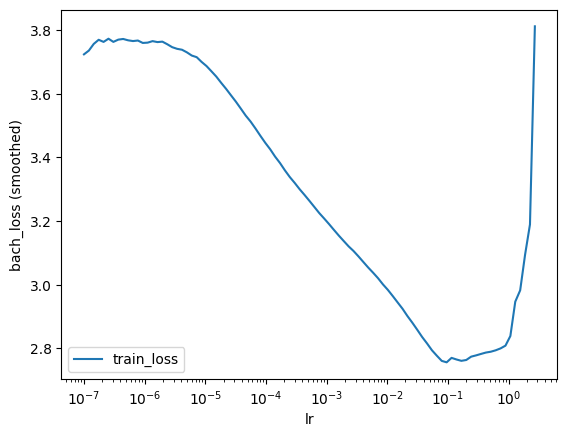

In [41]:
batch_size = 256

lrfinder = model.lr_finder(x_train, y_train, batch_size, tolerance=10)
_ = lrfinder.plot()

In [42]:
lrfinder.get_best_lr()

0.009545484566618261

In [43]:
model.optimizer.set_lr(0.01)

In [44]:
epochs = 512

callbacks = [tt.callbacks.EarlyStopping()]

# class GradientClippingCallback(tt.callbacks.Callback):
#     def __init__(self, clip_value=1.0):
#         self.clip_value = clip_value
#     def on_batch_end(self):
#         for p in self.model.net.parameters():
#             if p.grad is not None:
#                 torch.nn.utils.clip_grad_value_(p, self.clip_value)

# callbacks = [tt.callbacks.EarlyStopping(), GradientClippingCallback(1.0)]

verbose = True

In [45]:
%%time
log = model.fit(x_train, y_train, batch_size, epochs, callbacks, verbose,
                val_data=val, val_batch_size=batch_size)

0:	[0s / 0s],		train_loss: 3.7798,	val_loss: 33.7280
1:	[0s / 0s],		train_loss: 3.2697,	val_loss: 3.6448
2:	[0s / 0s],		train_loss: 3.1891,	val_loss: 2.5871
3:	[0s / 0s],		train_loss: 3.1252,	val_loss: 2.2514
4:	[0s / 0s],		train_loss: 3.0690,	val_loss: 2.1041
5:	[0s / 0s],		train_loss: 3.0469,	val_loss: 2.0355
6:	[0s / 0s],		train_loss: 3.0650,	val_loss: 2.0129
7:	[0s / 0s],		train_loss: 3.0046,	val_loss: 2.0102
8:	[0s / 0s],		train_loss: 3.0744,	val_loss: 2.0151
9:	[0s / 0s],		train_loss: 2.9307,	val_loss: 2.0338
10:	[0s / 0s],		train_loss: 2.9776,	val_loss: 2.0592
11:	[0s / 0s],		train_loss: 2.8929,	val_loss: 2.0892
12:	[0s / 0s],		train_loss: 2.8307,	val_loss: 2.1300
13:	[0s / 0s],		train_loss: 2.8733,	val_loss: 2.1658
14:	[0s / 0s],		train_loss: 2.8283,	val_loss: 2.2020
15:	[0s / 0s],		train_loss: 2.8059,	val_loss: 2.2436
16:	[0s / 0s],		train_loss: 2.7909,	val_loss: 2.2863
17:	[0s / 0s],		train_loss: 2.7315,	val_loss: 2.3313
CPU times: user 13.1 s, sys: 198 ms, total: 13.3 s
Wall

Key patterns:

Training loss decreases steadily → the model is still fitting the training data.

Validation loss starts increasing at epoch 4–5 and then skyrockets → the model has overfitted badly and/or is becoming unstable.

The gap between train and val loss widens sharply → strong overfitting or gradient explosion.

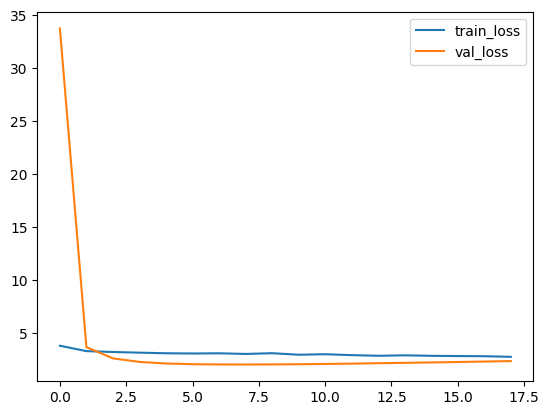

In [46]:
_ = log.plot()

In [47]:
model.partial_log_likelihood(*val).mean()

-2.0261273

### Prediction
For evaluation we first need to obtain survival estimates for the test set. This can be done with model.predict_surv which returns an array of survival estimates, or with model.predict_surv_df which returns the survival estimates as a dataframe.

However, as CoxPH is semi-parametric, we first need to get the non-parametric baseline hazard estimates with compute_baseline_hazards.

Note that for large datasets the sample argument can be used to estimate the baseline hazard on a subset.

In [48]:
_ = model.compute_baseline_hazards()

In [49]:
surv = model.predict_surv_df(x_test)   # index = training durations

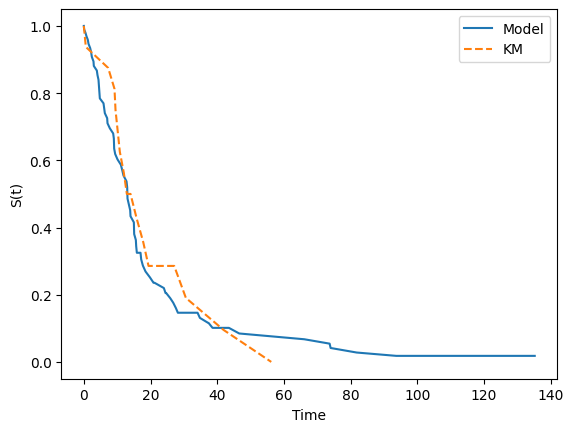

In [50]:
#%pip install lifelines
from lifelines import KaplanMeierFitter

# Kaplan–Meier on test set
kmf = KaplanMeierFitter()
kmf.fit(durations_test, events_test)
km_curve = pd.Series(kmf.survival_function_['KM_estimate'], name="KM")

# Model survival (mean across patients)
model_mean = surv.mean(axis=1)

plt.plot(model_mean.index, model_mean.values, label="Model")
plt.plot(km_curve.index, km_curve.values, label="KM", linestyle="--")
plt.xlabel("Time")
plt.ylabel("S(t)")
plt.legend()

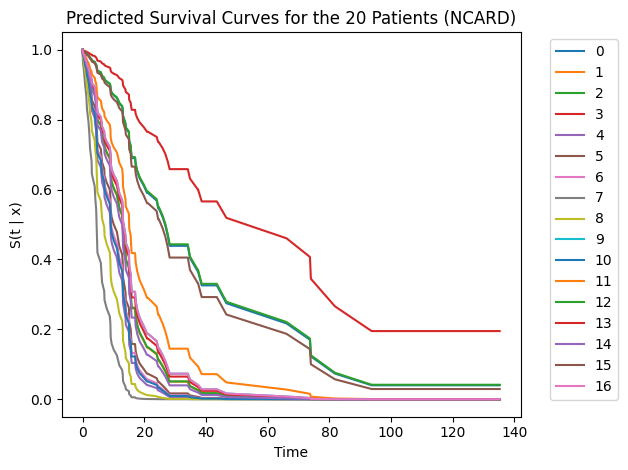

In [51]:
# Rename columns for the first 20
surv_subset = surv.iloc[:, :20]
# surv_subset.columns = [f'p_{i+1}' for i in range(surv_subset.shape[1])]

# Plot with new legend
surv_subset.plot()
plt.ylabel('S(t | x)')  # conditional survival function
plt.xlabel('Time')
plt.title('Predicted Survival Curves for the 20 Patients (NCARD)')

# Move legend outside
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

### Evaluation

We can use the EvalSurv class for evaluation the concordance, brier score and binomial log-likelihood. Setting censor_surv='km' means that we estimate the censoring distribution by Kaplan-Meier on the test set.

In [52]:
ev = EvalSurv(surv, durations_test, events_test, censor_surv='km')
ev.concordance_td()

0.6576576576576577

time-dependent concordance index (C-index)：

0.5 = random guessing,

1.0 = perfect discrimination,

0.656 = your model is indeed learning something predictive — better than random, but with room for improvement.

Text(0.5, 1.0, 'Brier Score Over Time')

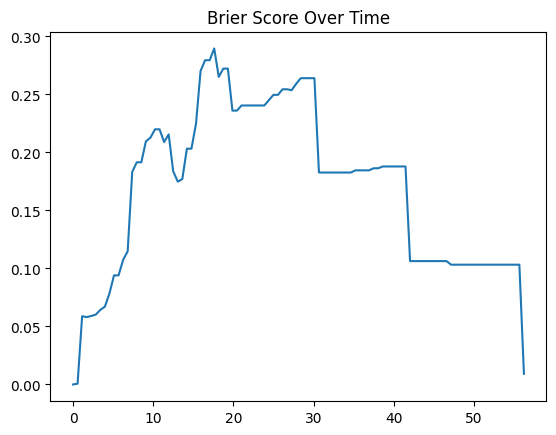

In [53]:
#computes the Brier score (squared error between predicted survival probability and observed outcome) at each time point.
time_grid = np.linspace(durations_test.min(), durations_test.max(), 100)
_ = ev.brier_score(time_grid).plot()

plt.title("Brier Score Over Time")

In [54]:
#make the current scipy work by xiao
import scipy.integrate

# Patch: alias simps → simpson for compatibility
if not hasattr(scipy.integrate, "simps"):
    scipy.integrate.simps = scipy.integrate.simpson

ev.integrated_brier_score(time_grid) 

ibs = ev.integrated_brier_score(time_grid)
print("Integrated Brier Score:", ibs)

Integrated Brier Score: 0.1706477101299079


### Hyperparameter Tuning

In [55]:
# from sklearn.model_selection import ParameterGrid

# param_grid = {
#     'num_nodes': [[8, 8], [16, 16], [32, 16], [32, 32], [64, 32], [16, 16, 16], [32, 32, 32], [64, 32, 32]],
#     'dropout': [0.0005, 0.005, 0.05, 0.1, 0.2],
#     'batch_norm': [True, False],
#     'learning_rate': [1e-5, 1e-4, 1e-3, 1e-2, 1e-1],
#     'batch_size': [32, 64, 128, 256, 512]
# }

# results = []

# for params in ParameterGrid(param_grid):
#     #print(f"\nTesting params: {params}")
    
#     net = tt.practical.MLPVanilla(
#         in_features=x_train.shape[1],
#         num_nodes=params['num_nodes'],
#         out_features=1,
#         batch_norm=params['batch_norm'],
#         dropout=params['dropout']
#     )

#     model = CoxPH(net, tt.optim.Adam)
#     model.optimizer.set_lr(params['learning_rate'])
#     batch_size = params['batch_size']

#     callbacks = [tt.callbacks.EarlyStopping(patience=20)]
    
#     _ = model.fit(x_train, y_train, batch_size, 512, callbacks, verbose=False, val_data=val)

#     _ = model.compute_baseline_hazards()
#     surv_val = model.predict_surv_df(x_val)
#     ev = EvalSurv(surv_val, y_val[0], y_val[1], censor_surv='km')
#     c_index = ev.concordance_td()

#     #print(f"C-index (val): {c_index:.4f}")

#     results.append({
#         **params,
#         'c_index': c_index
#     })


In [56]:
# results_df = pd.DataFrame(results).sort_values('c_index', ascending=False)
# results_df.head(20)